# PAC Report for best submission


In [47]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import mean_squared_error, roc_auc_score
from scipy.optimize import differential_evolution

# Load data
train = pd.read_csv('analysis_data.csv')
test = pd.read_csv('scoring_data.csv')

train.head()

,customer_id,age,gender,marital_status,num_children,education_level,region,employment_status,owns_home,has_auto_loan,...,credit_limit,tenure,card_type,num_transactions,avg_transaction_value,online_shopping_freq,reward_points_balance,travel_frequency,utility_payment_count,monthly_spend
0,75570383,77,female,married,2,high school,midwest,student,1,0,...,1600,11,platinum,5,102,2.0,2103,0,2.0,573.78
1,77915507,52,male,married,0,high school,west,employed,1,1,...,1600,1,standard,12,39,4.0,4483,0,1.0,103.15
2,31958910,48,female,married,0,bachelors,west,student,1,0,...,2500,7,platinum,9,26,5.0,2383,1,4.0,297.28
3,76868487,67,female,married,3,high school,west,student,1,0,...,2900,7,gold,6,41,5.0,3263,1,1.0,353.81
4,69435006,21,female,single,0,bachelors,west,employed,0,0,...,2300,8,gold,8,44,4.0,2415,0,NaN,392.83


In [59]:
# data type
print(train.dtypes.to_list())
train.info(verbose=True)

[dtype('int64'), dtype('int64'), <StringDtype(na_value=nan)>, <StringDtype(na_value=nan)>, dtype('int64'), <StringDtype(na_value=nan)>, <StringDtype(na_value=nan)>, <StringDtype(na_value=nan)>, dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), dtype('int64'), <StringDtype(na_value=nan)>, dtype('int64'), dtype('int64'), dtype('float64'), dtype('int64'), dtype('int64'), dtype('float64'), dtype('float64')]
<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            40000 non-null  int64  
 1   age                    40000 non-null  int64  
 2   gender                 40000 non-null  str    
 3   marital_status         40000 non-null  str    
 4   num_children           40000 non-null  int64  
 5   education_level        39089 non-null  str    
 6   region                 40000

In [61]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy.stats import skew

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print(f"Train: {train.shape}, Test: {test.shape}")

missing = train.isnull().sum().sort_values(ascending=False)

print(missing[missing > 0])

Train: (40000, 23), Test: (10000, 22)
utility_payment_count    1378
online_shopping_freq     1364
education_level           911
dtype: int64


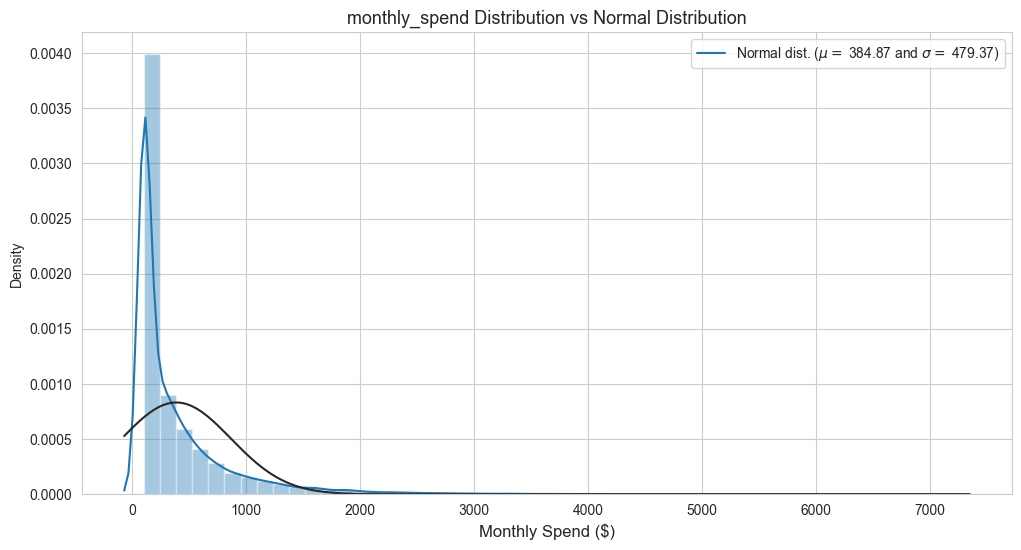

In [63]:
# ── Distribution of monthly_spend ──
(mu, sigma) = norm.fit(train['monthly_spend'])

plt.figure(figsize=(12, 6))
sns.distplot(train['monthly_spend'], kde=True, hist=True, fit=norm)
plt.title('monthly_spend Distribution vs Normal Distribution', fontsize=13)
plt.xlabel('Monthly Spend ($)', fontsize=12)
plt.legend(['Normal dist. ($\\mu=$ {:.2f} and $\\sigma=$ {:.2f})'.format(mu, sigma)],
           loc='best')
plt.show()

Findings:- Floor customers: avg credit_score 636, avg credit_limit 
3,331- The distributions clearly differ but overlap heavily — no single threshold separates themArchitectural decision: train a dedicated LightGBM classifier on is_floor. It achieves AUC 0.961 out-of-fold. The classifier's probability becomes a feature for the regression stage. This is the single most impactful design decision in the project.

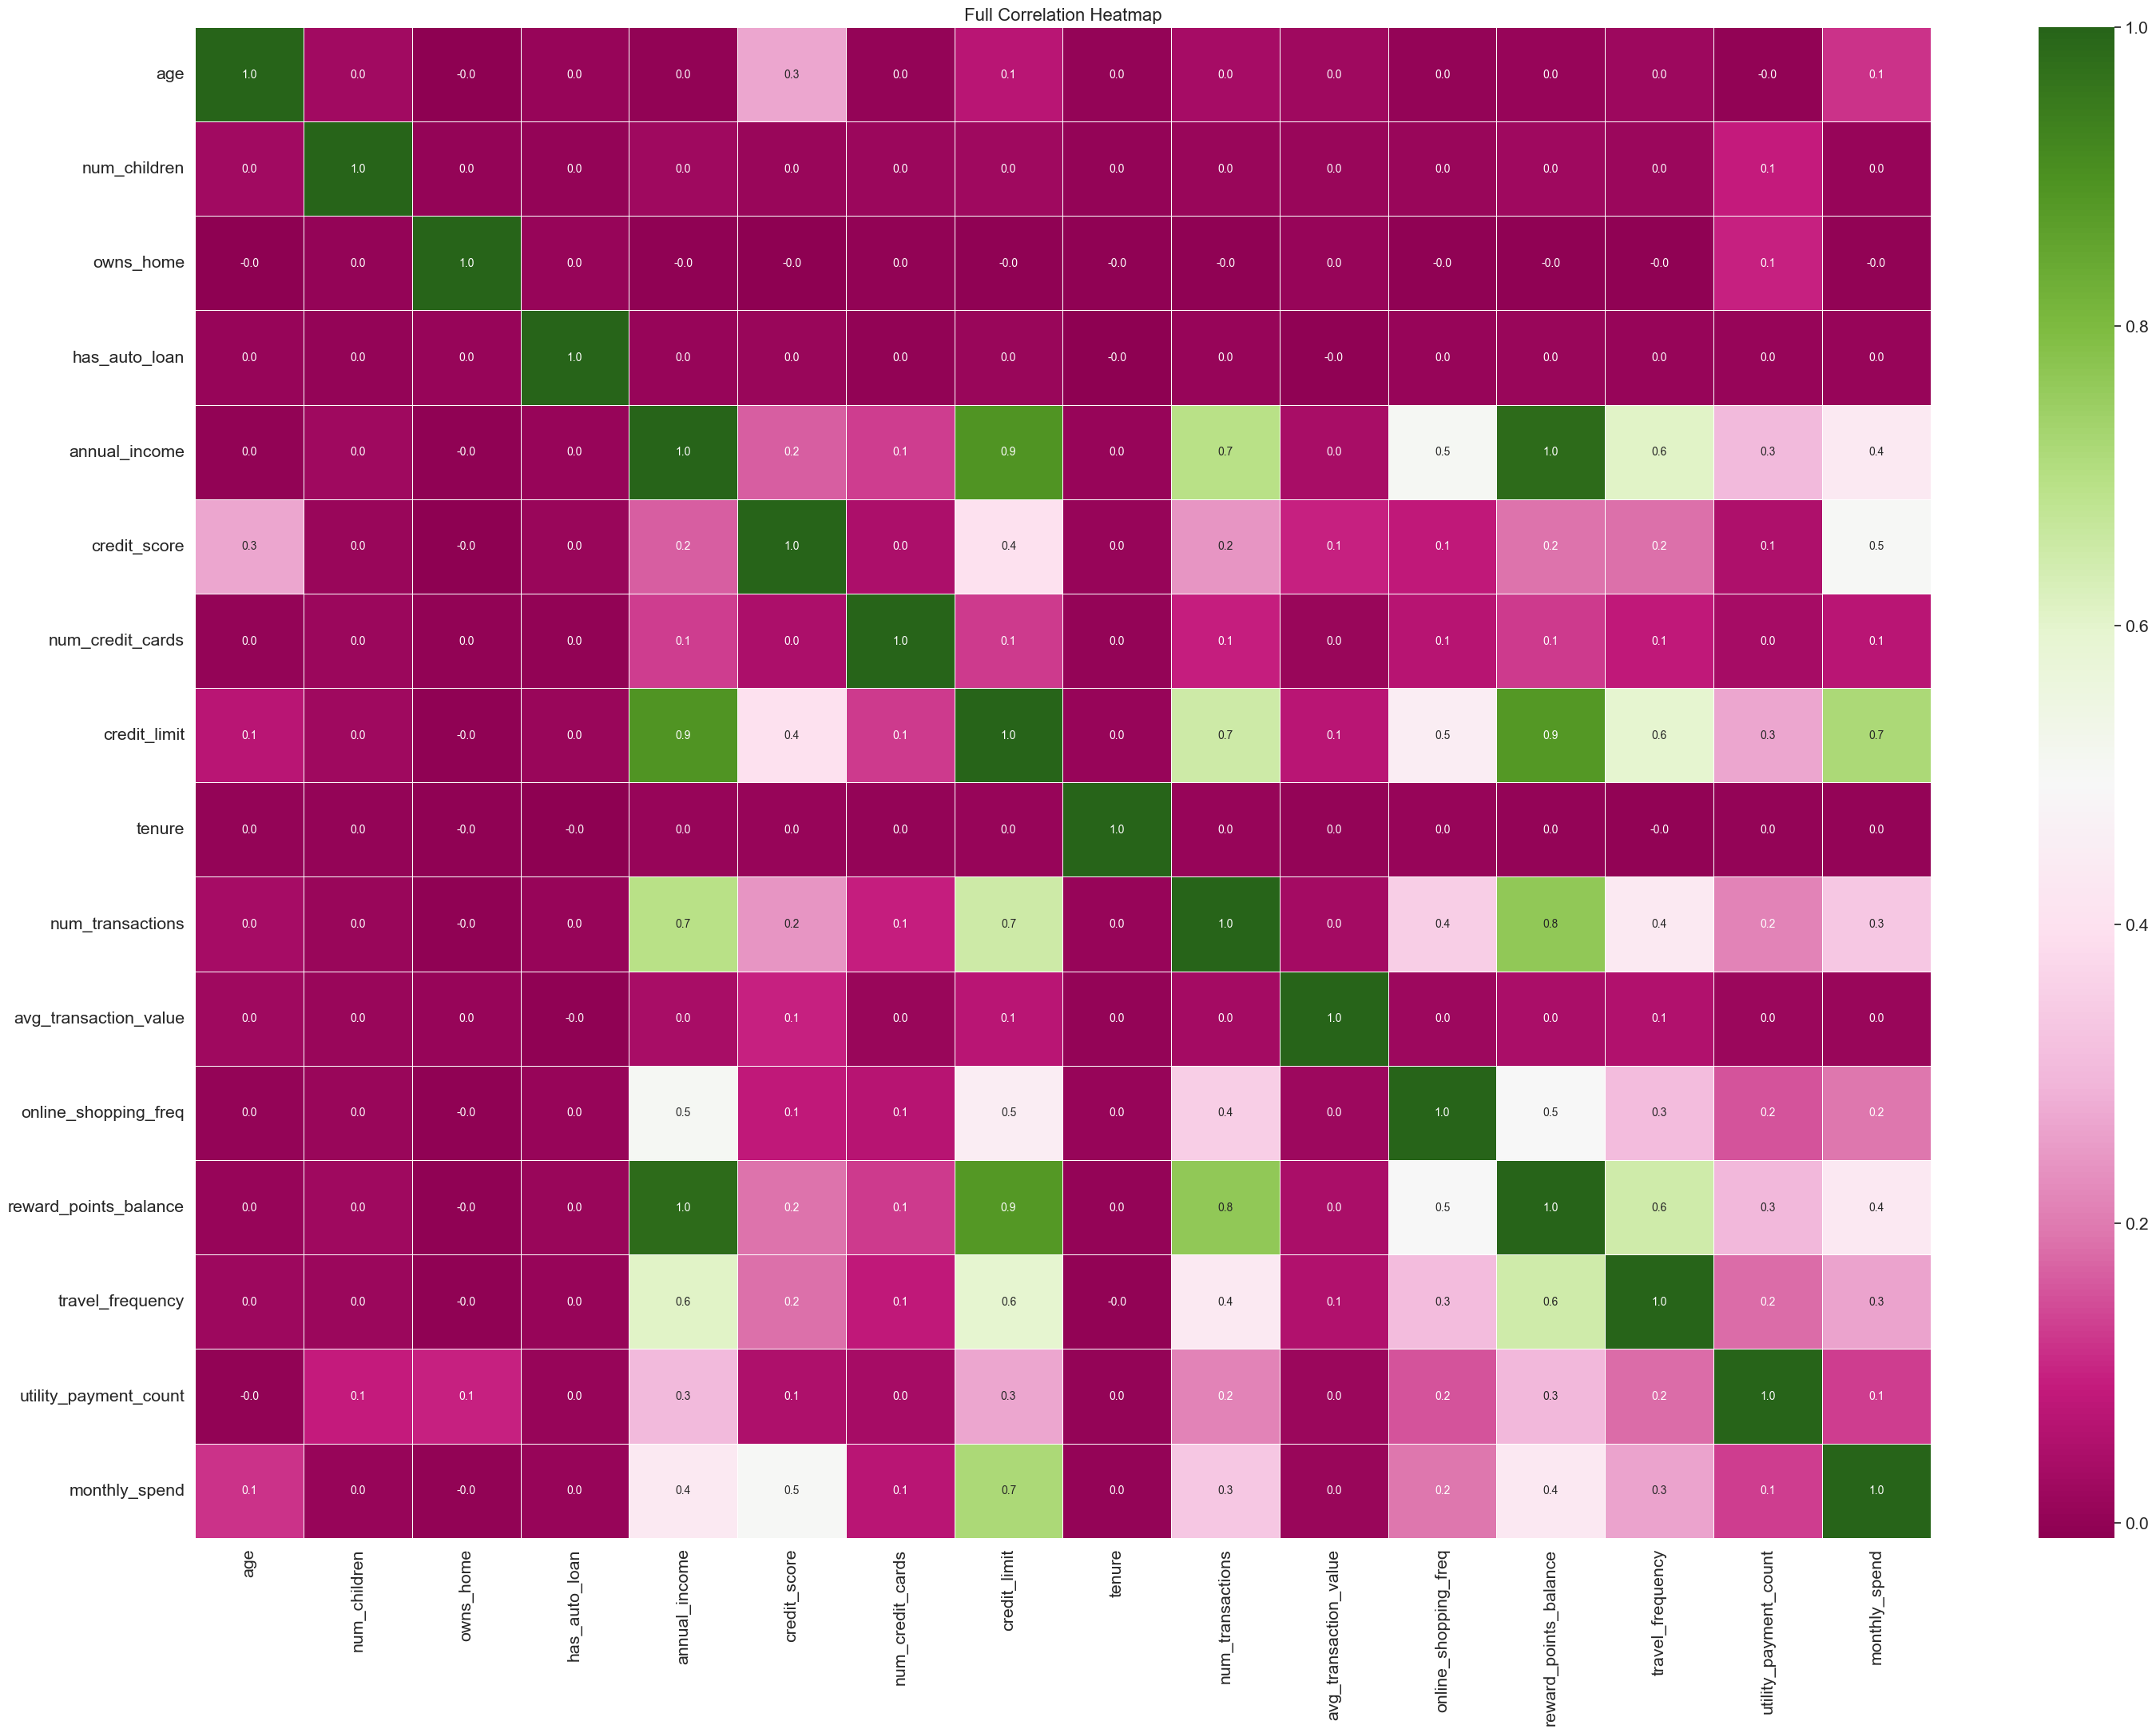

In [65]:
# ── Correlation heatmap (all numeric features) ──
numeric_train = train.select_dtypes(include=[np.number]).drop(columns=['customer_id'], errors='ignore')
correlation_train = numeric_train.corr()

sns.set(font_scale=1.4)
plt.figure(figsize=(30, 22))
ax = sns.heatmap(correlation_train, annot=True, annot_kws={"size": 10},
                 fmt='.1f', cmap='PiYG', linewidths=.5)
plt.title('Full Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

Pearson correlations with monthly_spend:- credit_limit: 0.72 (strongest)- credit_score: 0.50- annual_income: 0.43- reward_points_balance: 0.43Collinearity warning: the three predictors credit_limit, annual_income, reward_points_balance are essentially the same signal:- credit_limit ↔ annual_income: 0.89- credit_limit ↔ reward_points: 0.88- annual_income ↔ reward_points: 0.98This will destroy linear models.

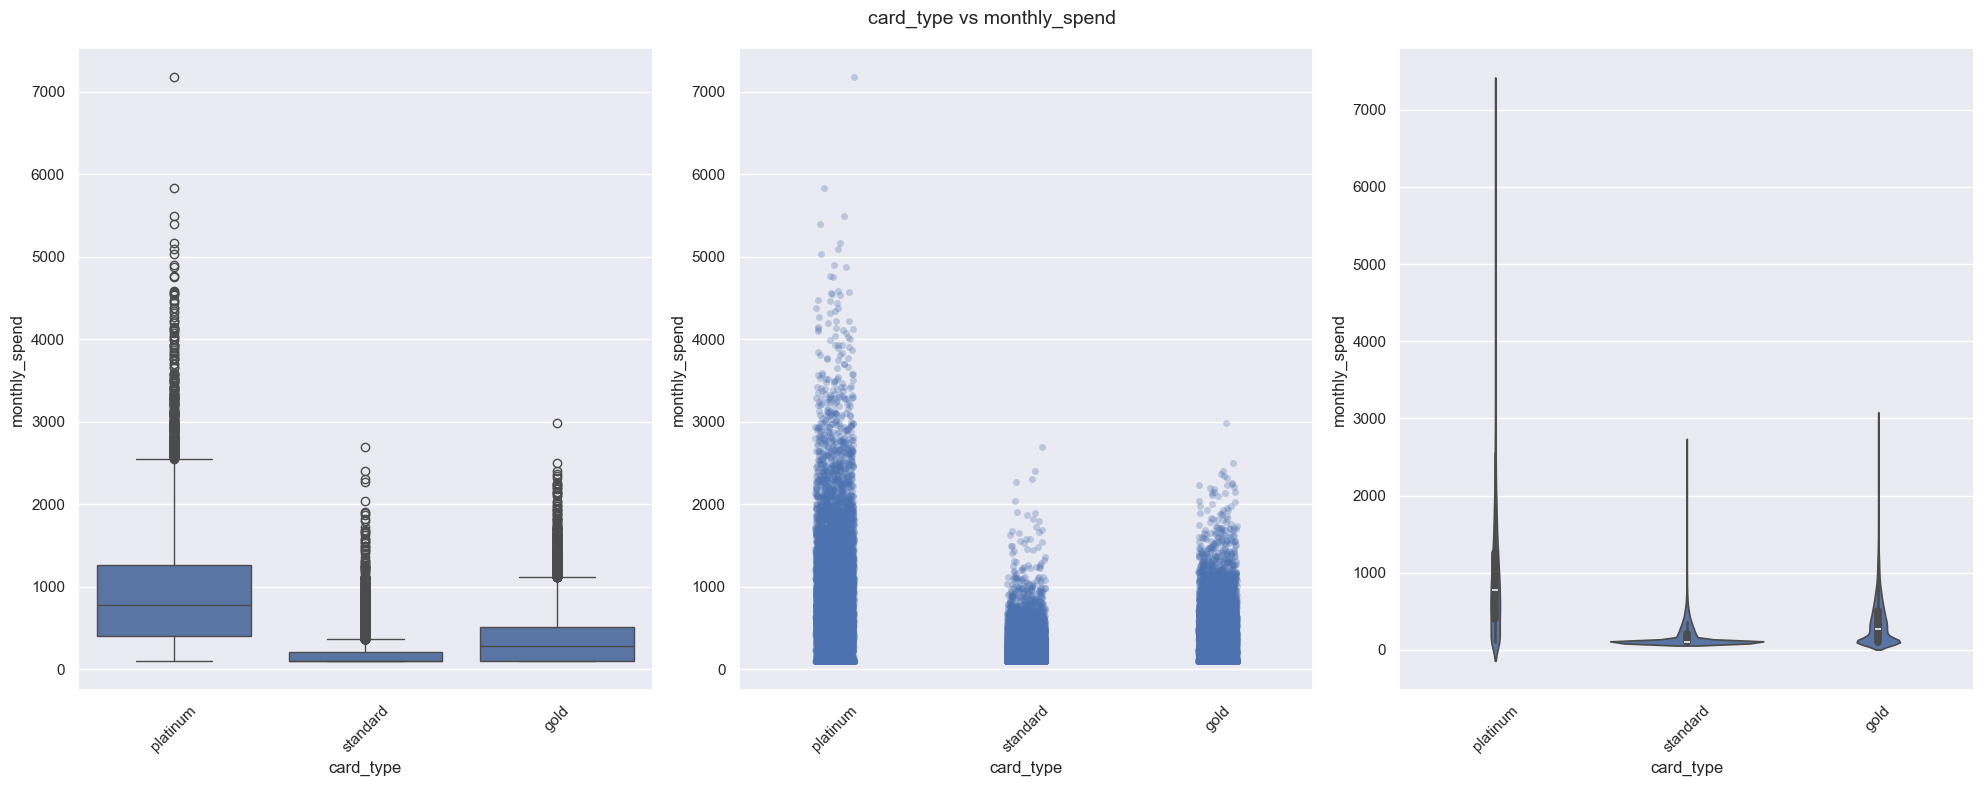

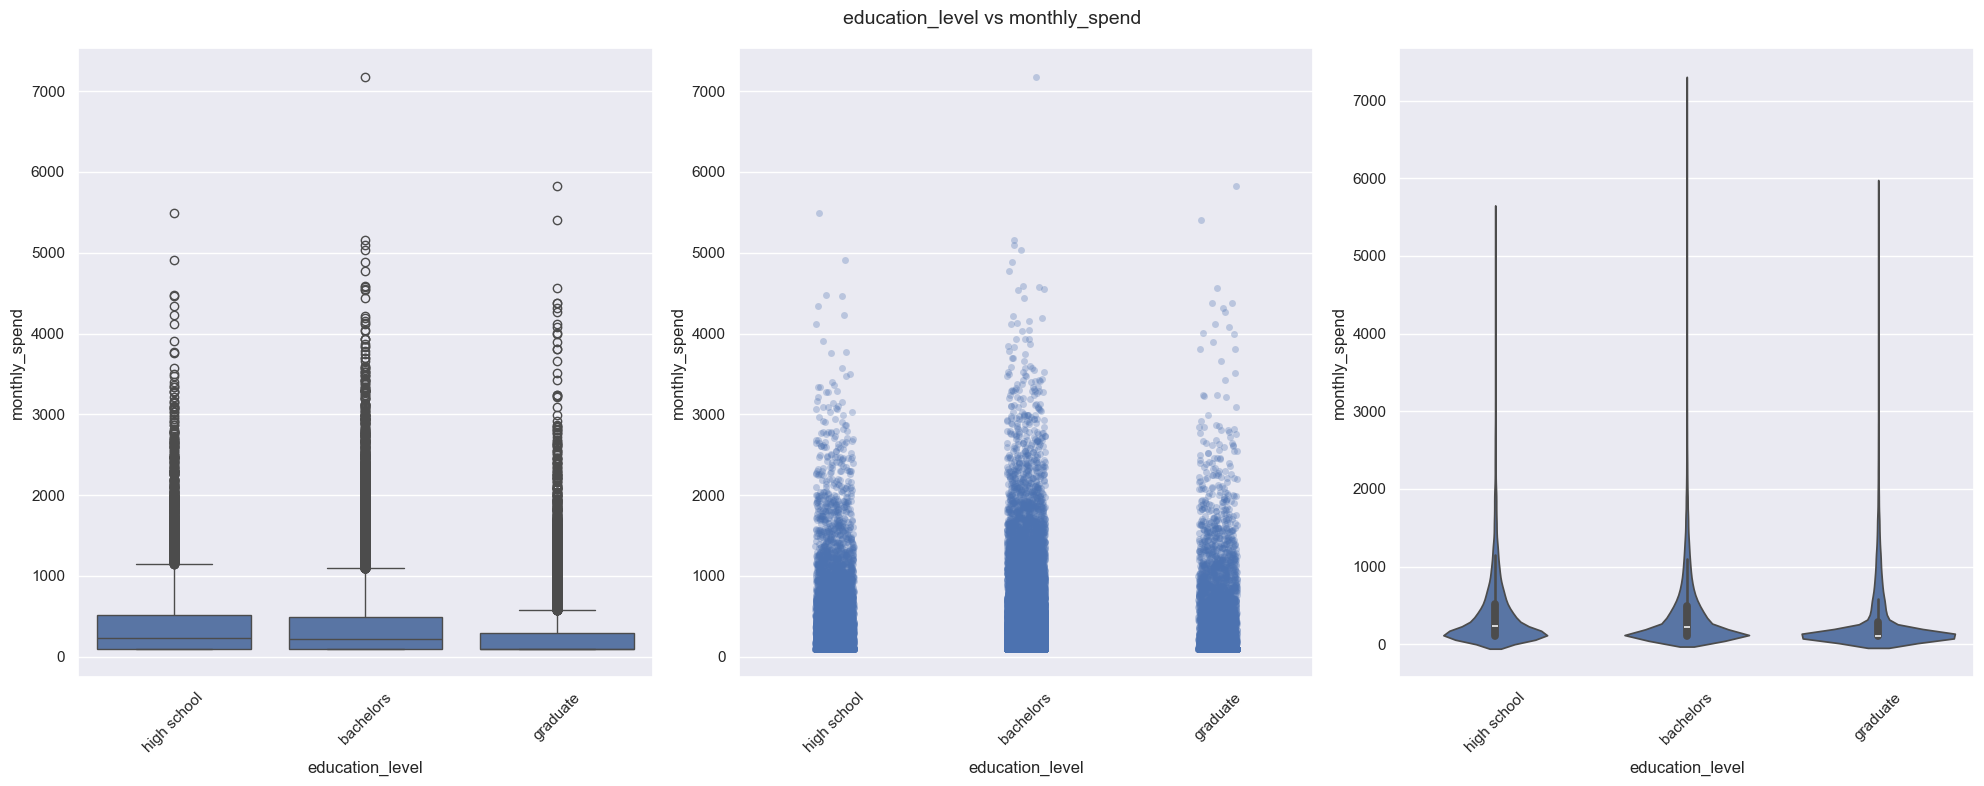

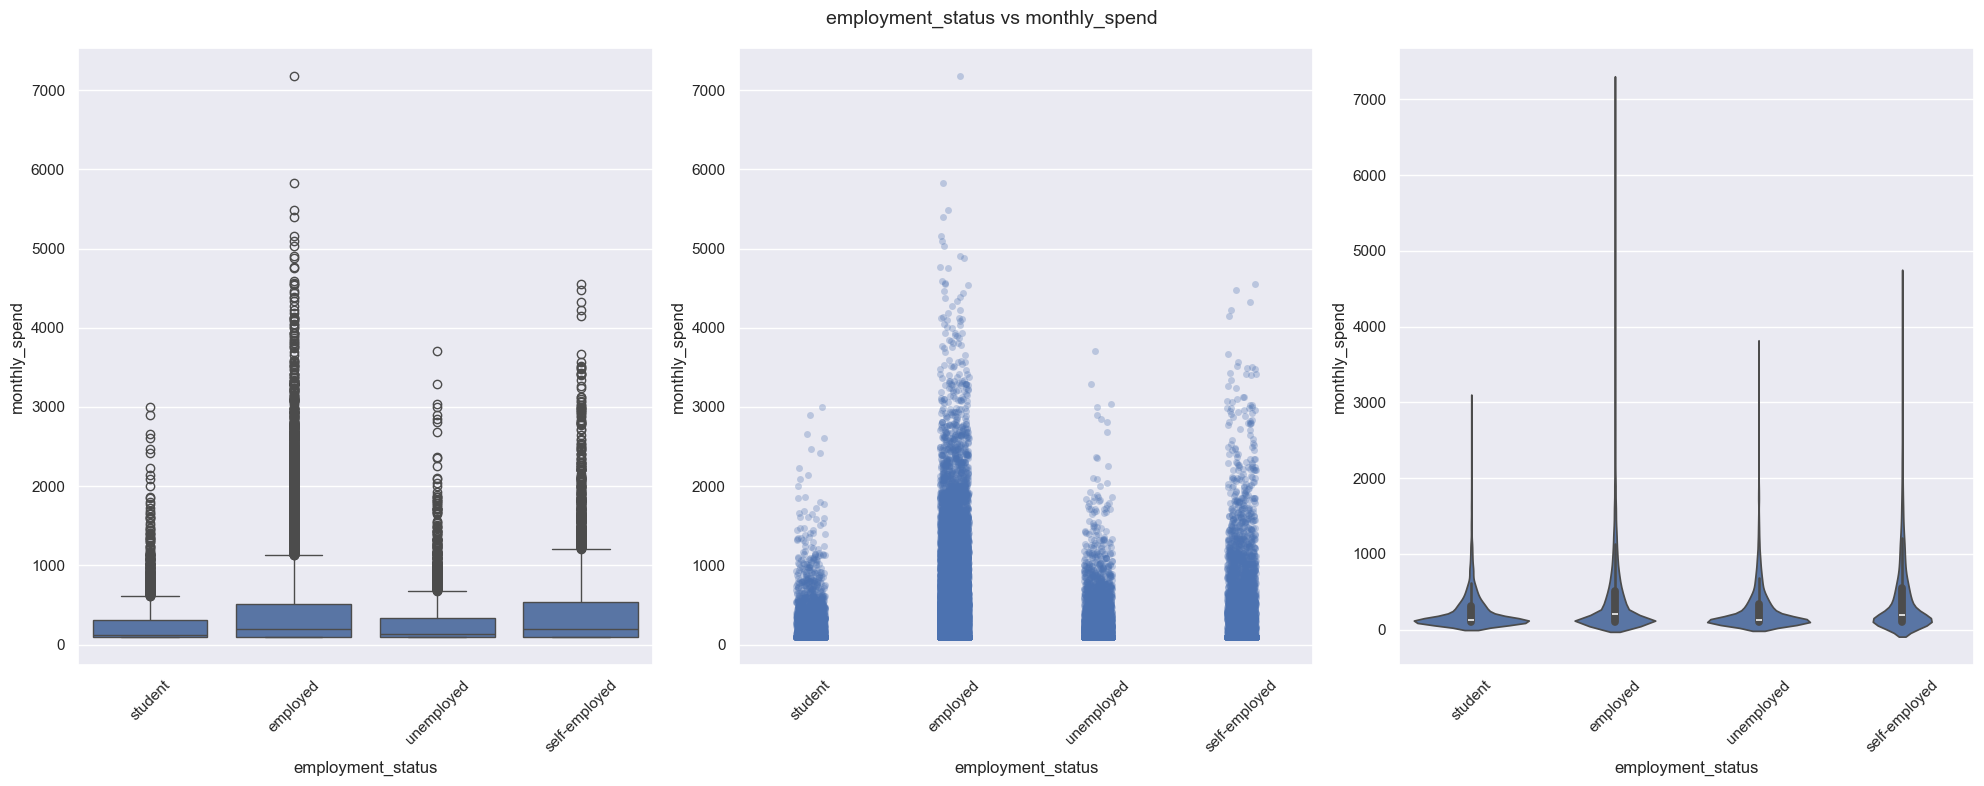

In [69]:
# ── Box / Violin / Strip plots for key categorical vs target ──
for cat_col in ['card_type', 'education_level', 'employment_status']:
    sns.set(font_scale=1)
    fig, ax = plt.subplots(1, 3, figsize=(20, 8))
    sns.boxplot(data=train, x=cat_col, y='monthly_spend', ax=ax[0])
    sns.stripplot(data=train, x=cat_col, y='monthly_spend', ax=ax[1], alpha=0.3)
    sns.violinplot(data=train, x=cat_col, y='monthly_spend', ax=ax[2])
    for a in ax:
        a.tick_params(axis='x', rotation=45)
    fig.suptitle(f'{cat_col} vs monthly_spend', fontsize=14)
    plt.tight_layout()
    plt.show()

Card tier matters: **standard** cards hug the $100 floor; **platinum** has the highest median spend (~$780) and widest spread.

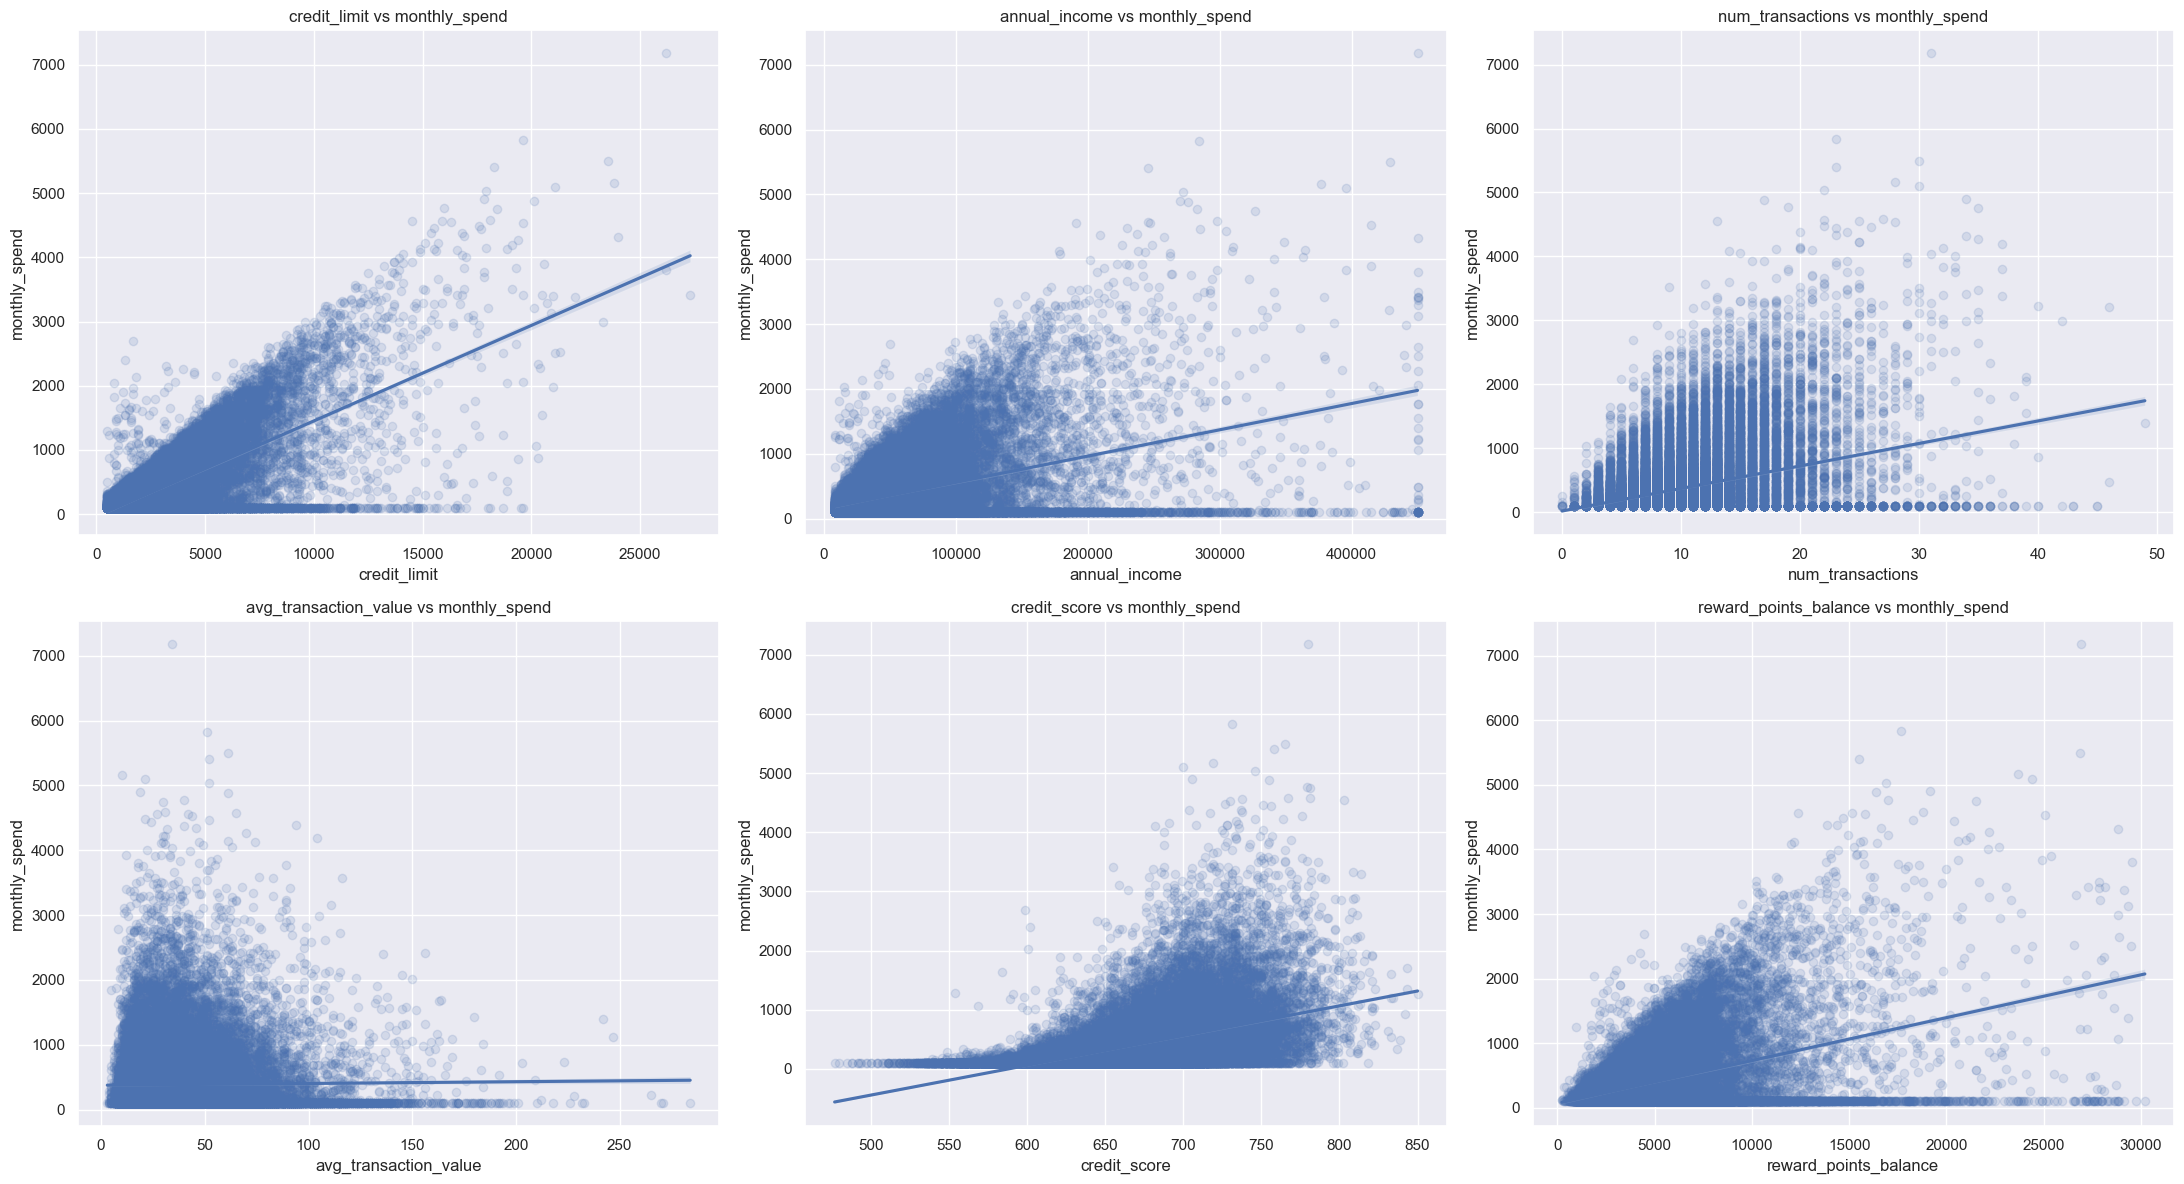

In [72]:
# ── Regression scatter plots for top continuous predictors ──
cont_cols = ['credit_limit', 'annual_income', 'num_transactions', 'avg_transaction_value',
             'credit_score', 'reward_points_balance']

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
for ax, col in zip(axes.ravel(), cont_cols):
    sns.regplot(data=train, x=col, y='monthly_spend',
                scatter_kws={'alpha': 0.15}, ax=ax)
    ax.set_title(f'{col} vs monthly_spend')
plt.tight_layout()
plt.show()

The dense horizontal band at y=100 is visible in every scatter plot. It cuts across all credit_limits, all credit_scores, all incomes. The floor is not a function of any single feature — it's a behavioral pattern requiring its own classifier.

In [73]:
# ── Skewness check on target ──
print(f"Skewness of monthly_spend: {skew(train['monthly_spend']):.4f}")
print(f"Floor (=100) count: {(train['monthly_spend'] == 100).sum()} / {len(train)}")

Skewness of monthly_spend: 3.1021
Floor (=100) count: 16363 / 40000


In [25]:
# Combine two dataset
y = train['monthly_spend'].values
feature_cols = [c for c in train.columns if c not in ['customer_id', 'monthly_spend']]
n_train = len(train)
combined = pd.concat([train[feature_cols], test[feature_cols]], ignore_index=True)

In [31]:
# LABEL ENCODE STRINGS  +  FILL NaN WITH -1
str_cols = combined.select_dtypes(include=['object', 'string']).columns.tolist()
for col in str_cols:
    mp = {v: i for i, v in enumerate(combined[col].dropna().unique())}
    combined[col] = combined[col].map(mp)
combined = combined.fillna(-1)

In [33]:
# TARGET ENCODING (out-of-fold to prevent leakage)

cat_te = ['gender', 'marital_status', 'education_level', 'region',
          'employment_status', 'card_type', 'num_children', 'owns_home',
          'has_auto_loan', 'num_credit_cards']
kf_te = KFold(n_splits=5, shuffle=True, random_state=99)
for col in cat_te:
    te_tr = np.full(n_train, y.mean())
    ca = combined[col].iloc[:n_train].values
    for ti, vi in kf_te.split(np.arange(n_train)):
        for val in np.unique(ca[vi]):
            m_tr = ca[ti] == val
            m_vi = ca[vi] == val
            if m_tr.sum() > 0:
                te_tr[vi[m_vi]] = y[ti][m_tr].mean()
    te_te = np.full(len(test), y.mean())
    ct = combined[col].iloc[n_train:].values
    for val in np.unique(ct):
        m = ca == val
        if m.sum() > 0:
            te_te[ct == val] = y[m].mean()
    combined[f'{col}_te'] = np.concatenate([te_tr, te_te])

In [35]:
# FREQUENCY ENCODING
for col in str_cols:
    freq = combined[col].value_counts(normalize=True)
    combined[f'{col}_freq'] = combined[col].map(freq)

# FEATURE ENGINEERING

c = combined
c['total_txn_value'] = c['num_transactions'] * c['avg_transaction_value']
c['income_to_limit'] = c['annual_income'] / (c['credit_limit'] + 1)
c['income_per_card'] = c['annual_income'] / (c['num_credit_cards'] + 1)
c['limit_per_card'] = c['credit_limit'] / (c['num_credit_cards'] + 1)
c['score_x_limit'] = c['credit_score'] * c['credit_limit']
c['score_x_income'] = c['credit_score'] * c['annual_income']
c['score_x_txn'] = c['credit_score'] * c['num_transactions']
c['online_ratio'] = c['online_shopping_freq'] / (c['num_transactions'] + 1)
c['reward_per_txn'] = c['reward_points_balance'] / (c['num_transactions'] + 1)
c['reward_per_limit'] = c['reward_points_balance'] / (c['credit_limit'] + 1)
c['utility_ratio'] = c['utility_payment_count'] / (c['num_transactions'] + 1)
c['avg_txn_x_online'] = c['avg_transaction_value'] * c['online_shopping_freq']
c['travel_x_income'] = c['travel_frequency'] * c['annual_income']
c['children_x_income'] = c['num_children'] * c['annual_income']
c['age_x_income'] = c['age'] * c['annual_income']
c['age_x_score'] = c['age'] * c['credit_score']
c['tenure_ratio'] = c['tenure'] / (c['age'] + 1)
c['credit_limit_sq'] = c['credit_limit'] ** 2
c['credit_score_sq'] = c['credit_score'] ** 2
c['log_income'] = np.log1p(c['annual_income'].clip(0))
c['log_limit'] = np.log1p(c['credit_limit'].clip(0))
c['log_reward'] = np.log1p(c['reward_points_balance'].clip(0))
c['txn_per_tenure'] = c['num_transactions'] / (c['tenure'] + 1)
c['spend_capacity'] = c['credit_limit'] * c['num_transactions']
c['limit_util_proxy'] = c['total_txn_value'] / (c['credit_limit'] + 1)
c['reward_per_income'] = c['reward_points_balance'] / (c['annual_income'] + 1)
c['score_bucket'] = (c['credit_score'] // 50).astype(int)
c['limit_x_score_x_txn'] = c['credit_limit'] * c['credit_score'] * c['num_transactions']
c['income_x_txn'] = c['annual_income'] * c['num_transactions']
c['log_txn_value'] = np.log1p(c['total_txn_value'].clip(0))
c['score_above_650'] = (c['credit_score'] > 650).astype(int)
c['high_income'] = (c['annual_income'] > 50000).astype(int)
c['score_x_high_income'] = c['credit_score'] * c['high_income']
c['limit_x_online'] = c['credit_limit'] * c['online_shopping_freq']
c['reward_x_travel'] = c['reward_points_balance'] * c['travel_frequency']
c['income_sq'] = c['annual_income'] ** 2
c['limit_to_income'] = c['credit_limit'] / (c['annual_income'] + 1)
c.replace([np.inf, -np.inf], -1, inplace=True)

X_tr = c.iloc[:n_train].values
X_te = c.iloc[n_train:].values
is_floor = (y == 100.0).astype(int)
print(f"Features: {c.shape[1]}, Floor samples: {is_floor.sum()}/{len(y)}")

Features: 68, Floor samples: 16363/40000


In [37]:
# STAGE 1 — CLASSIFIER (predict floor=100 vs not)
# 41% of targets are exactly 100.0; classifier prob is a strong meta-feature.

N = 5
skf = StratifiedKFold(n_splits=N, shuffle=True, random_state=42)
cls_oof, cls_te = np.zeros(n_train), np.zeros(len(X_te))
for f, (ti, vi) in enumerate(skf.split(X_tr, is_floor)):
    m = lgb.LGBMClassifier(
        objective='binary', n_estimators=800, learning_rate=0.05, num_leaves=63,
        feature_fraction=0.7, bagging_fraction=0.7, bagging_freq=5,
        min_child_samples=20, reg_alpha=0.1, reg_lambda=0.1,
        verbosity=-1, random_state=42)
    m.fit(X_tr[ti], is_floor[ti], eval_set=[(X_tr[vi], is_floor[vi])],
          callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
    cls_oof[vi] = m.predict_proba(X_tr[vi])[:, 1]
    cls_te += m.predict_proba(X_te)[:, 1] / N
print(f"Classifier AUC: {roc_auc_score(is_floor, cls_oof):.4f}")

# Augment features with classifier probability
X_tr_aug = np.column_stack([X_tr, cls_oof])
X_te_aug = np.column_stack([X_te, cls_te])

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[229]	valid_0's binary_logloss: 0.240465


D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[245]	valid_0's binary_logloss: 0.246364


D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[216]	valid_0's binary_logloss: 0.252471


D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[200]	valid_0's binary_logloss: 0.248568


D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[170]	valid_0's binary_logloss: 0.250689
Classifier AUC: 0.9613


D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [39]:
# STAGE 2 — TRAIN DIVERSE REGRESSORS

kf = KFold(n_splits=N, shuffle=True, random_state=42)
kf2 = KFold(n_splits=N, shuffle=True, random_state=123)
all_oof, all_te, model_names = [], [], []

def add(name, oof, te):
    rmse = np.sqrt(mean_squared_error(y, oof))
    print(f"  {name}: RMSE={rmse:.4f}")
    all_oof.append(oof.copy()); all_te.append(te.copy()); model_names.append(name)

# A: LightGBM
oof, te = np.zeros(len(y)), np.zeros(len(X_te_aug))
for f, (ti, vi) in enumerate(kf.split(X_tr_aug)):
    m = lgb.LGBMRegressor(objective='regression', n_estimators=800, learning_rate=0.05,
        num_leaves=63, feature_fraction=0.7, bagging_fraction=0.7, bagging_freq=5,
        min_child_samples=20, reg_alpha=0.1, reg_lambda=0.1, verbosity=-1, random_state=42)
    m.fit(X_tr_aug[ti], y[ti], eval_set=[(X_tr_aug[vi], y[vi])],
          callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
    oof[vi] = m.predict(X_tr_aug[vi]); te += m.predict(X_te_aug) / N
add('LGBM', oof, te)

# B: LightGBM seed 123
oof, te = np.zeros(len(y)), np.zeros(len(X_te_aug))
for f, (ti, vi) in enumerate(kf2.split(X_tr_aug)):
    m = lgb.LGBMRegressor(objective='regression', n_estimators=800, learning_rate=0.05,
        num_leaves=63, feature_fraction=0.7, bagging_fraction=0.7, bagging_freq=5,
        min_child_samples=20, reg_alpha=0.1, reg_lambda=0.1, verbosity=-1, random_state=123)
    m.fit(X_tr_aug[ti], y[ti], eval_set=[(X_tr_aug[vi], y[vi])],
          callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
    oof[vi] = m.predict(X_tr_aug[vi]); te += m.predict(X_te_aug) / N
add('LGBM_s123', oof, te)

# C: XGBoost
oof, te = np.zeros(len(y)), np.zeros(len(X_te_aug))
for f, (ti, vi) in enumerate(kf.split(X_tr_aug)):
    m = xgb.XGBRegressor(n_estimators=800, learning_rate=0.05, max_depth=6,
        subsample=0.7, colsample_bytree=0.7, reg_alpha=0.1, reg_lambda=0.1,
        verbosity=0, random_state=42, early_stopping_rounds=50)
    m.fit(X_tr_aug[ti], y[ti], eval_set=[(X_tr_aug[vi], y[vi])], verbose=False)
    oof[vi] = m.predict(X_tr_aug[vi]); te += m.predict(X_te_aug) / N
add('XGB', oof, te)

# D: XGBoost deeper
oof, te = np.zeros(len(y)), np.zeros(len(X_te_aug))
for f, (ti, vi) in enumerate(kf.split(X_tr_aug)):
    m = xgb.XGBRegressor(n_estimators=800, learning_rate=0.03, max_depth=8,
        subsample=0.7, colsample_bytree=0.6, reg_alpha=0.5, reg_lambda=1.0,
        verbosity=0, random_state=42, early_stopping_rounds=50)
    m.fit(X_tr_aug[ti], y[ti], eval_set=[(X_tr_aug[vi], y[vi])], verbose=False)
    oof[vi] = m.predict(X_tr_aug[vi]); te += m.predict(X_te_aug) / N
add('XGB_deep', oof, te)

# E: CatBoost
oof, te = np.zeros(len(y)), np.zeros(len(X_te_aug))
for f, (ti, vi) in enumerate(kf.split(X_tr_aug)):
    m = CatBoostRegressor(iterations=800, learning_rate=0.05, depth=6,
        l2_leaf_reg=3, random_seed=42, verbose=0, early_stopping_rounds=50)
    m.fit(X_tr_aug[ti], y[ti], eval_set=(X_tr_aug[vi], y[vi]), verbose=0)
    oof[vi] = m.predict(X_tr_aug[vi]); te += m.predict(X_te_aug) / N
add('CatBoost', oof, te)

# F: CatBoost deeper (best single model)
oof, te = np.zeros(len(y)), np.zeros(len(X_te_aug))
for f, (ti, vi) in enumerate(kf.split(X_tr_aug)):
    m = CatBoostRegressor(iterations=800, learning_rate=0.05, depth=8,
        l2_leaf_reg=1, random_seed=42, verbose=0, early_stopping_rounds=50)
    m.fit(X_tr_aug[ti], y[ti], eval_set=(X_tr_aug[vi], y[vi]), verbose=0)
    oof[vi] = m.predict(X_tr_aug[vi]); te += m.predict(X_te_aug) / N
add('CatBoost_deep', oof, te)

# G: CatBoost seed 123
oof, te = np.zeros(len(y)), np.zeros(len(X_te_aug))
for f, (ti, vi) in enumerate(kf2.split(X_tr_aug)):
    m = CatBoostRegressor(iterations=800, learning_rate=0.05, depth=6,
        l2_leaf_reg=3, random_seed=123, verbose=0, early_stopping_rounds=50)
    m.fit(X_tr_aug[ti], y[ti], eval_set=(X_tr_aug[vi], y[vi]), verbose=0)
    oof[vi] = m.predict(X_tr_aug[vi]); te += m.predict(X_te_aug) / N
add('CatBoost_s123', oof, te)

# H: MLP (neural net for diversity)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_aug)
X_te_s = scaler.transform(X_te_aug)
oof, te = np.zeros(len(y)), np.zeros(len(X_te_aug))
for f, (ti, vi) in enumerate(kf.split(X_tr_s)):
    m = MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=100,
        early_stopping=True, random_state=42)
    m.fit(X_tr_s[ti], y[ti])
    oof[vi] = m.predict(X_tr_s[vi]); te += m.predict(X_te_s) / N
add('MLP', oof, te)

# I: Two-stage (classifier * 100 + (1-classifier) * non-floor regressor)
oof2, te2 = np.zeros(len(y)), np.zeros(len(X_te_aug))
for f, (ti, vi) in enumerate(kf.split(X_tr_aug)):
    mask = y[ti] != 100.0
    m = lgb.LGBMRegressor(objective='regression', n_estimators=800, learning_rate=0.05,
        num_leaves=63, feature_fraction=0.7, bagging_fraction=0.7, bagging_freq=5,
        min_child_samples=20, reg_alpha=0.1, reg_lambda=0.1, verbosity=-1, random_state=42)
    m.fit(X_tr_aug[ti][mask], y[ti][mask], eval_set=[(X_tr_aug[vi], y[vi])],
          callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
    oof2[vi] = m.predict(X_tr_aug[vi]); te2 += m.predict(X_te_aug) / N
ts_oof = cls_oof * 100 + (1 - cls_oof) * oof2
ts_te = cls_te * 100 + (1 - cls_te) * te2
add('TwoStage', ts_oof, ts_te)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[250]	valid_0's l2: 17759.4


D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[220]	valid_0's l2: 18978.5


D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[230]	valid_0's l2: 18853


...

D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Early stopping, best iteration is:
[150]	valid_0's l2: 39805.3
Training until validation scores don't improve for 50 rounds


D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Early stopping, best iteration is:
[120]	valid_0's l2: 34672.9
  TwoStage: RMSE=135.5883


D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [41]:
# JOINTLY OPTIMIZE BLEND WEIGHTS + POST-PROCESSING THRESHOLD

oof_stack = np.column_stack(all_oof)
te_stack = np.column_stack(all_te)
n_models = oof_stack.shape[1]

def objective(params):
    w = np.array(params[:-1])
    thresh = params[-1]
    w = w / (w.sum() + 1e-10)
    pred = oof_stack @ w
    pred[cls_oof > thresh] = 100.0
    pred = np.clip(pred, 100.0, None)
    return np.sqrt(mean_squared_error(y, pred))

bounds = [(0, 1)] * n_models + [(0.3, 0.95)]
res = differential_evolution(objective, bounds, seed=42, maxiter=200, tol=1e-6)
w_opt = np.array(res.x[:-1]); w_opt = w_opt / w_opt.sum()
thresh_opt = res.x[-1]

print(f"\nOptimal threshold: {thresh_opt:.4f}")
print(f"Final OOF RMSE: {res.fun:.4f}")
print("Optimal weights:")
for name, w in zip(model_names, w_opt):
    if w > 0.01:
        print(f"  {name}: {w:.4f}")


Optimal threshold: 0.9376
Final OOF RMSE: 124.8303
Optimal weights:
  LGBM_s123: 0.0230
  CatBoost_deep: 0.2388
  CatBoost_s123: 0.1533
  MLP: 0.5850


In [43]:
# GENERATE SUBMISSION

final = te_stack @ w_opt
final[cls_te > thresh_opt] = 100.0
final = np.clip(final, 100.0, None)

submission = pd.DataFrame({
    'customer_id': test['customer_id'],
    'monthly_spend': final
})

# submission.to_csv('submission_16.csv', index=False)
print(f"\nSubmission saved. Shape: {submission.shape}")
print(submission.head())


Submission saved. Shape: (10000, 2)
   customer_id  monthly_spend
0     20451981    2623.848936
1     23251656    1176.768224
2     64082260     279.166869
3     82505923     208.382674
4     89981994     145.016994
